# Public Wolffia Combined UMAP and Marker Review

This notebook combines the four public `Wolffia australiana` runs from `PRJNA1124135` into one cell-level analysis object.

The previous notebook compared run-level summary metrics. This notebook asks a more biological question: do the model-accepted labels occupy coherent native Wolffia expression neighborhoods after the four runs are analyzed together?


## tl;dr

- The four normalized public Wolffia matrices are combined into one AnnData object with run, dawn/dusk, QC, and model-label metadata.
- The notebook computes highly variable genes, PCA, neighbors, UMAP, and Leiden clusters on the combined public dataset.
- The main visual checks are UMAP by run, dawn/dusk condition, QC depth, Leiden cluster, and final transfer label.
- The key biological check is whether `photosynthetic_or_assimilation` cells form coherent Wolffia expression neighborhoods rather than scattering randomly.
- Cluster marker tables are generated for native Wolffia clusters so labels can be reviewed using Waus8730 genes and functional descriptions.


## Context & Methods

### Key assumptions

- Inputs are normalized/log1p AnnData objects generated from STARsolo filtered matrices.
- Transfer predictions were generated separately with the combined leaf-primary/root-benchmark model.
- UMAP and Leiden clustering are exploratory visualization tools. They support marker review, but they are not final biological validation by themselves.
- Accepted labels remain provisional broad-program predictions until they are supported by native Wolffia cluster markers and reproducibility across runs.

### External input location

```text
/Volumes/LaCie/wolffia_single_cell/results/processed_h5ad/
/Volumes/LaCie/wolffia_single_cell/results/model_application/<RUN>/
/Volumes/LaCie/wolffia_single_cell/results/waus8730_bridge/
```


In [1]:
from pathlib import Path
import os

# Make Scanpy/Matplotlib cache safely inside writable temp space.
os.environ.setdefault("NUMBA_CACHE_DIR", "/private/tmp/numba-cache")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")
Path(os.environ["NUMBA_CACHE_DIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc

plt.style.use("default")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
sc.settings.verbosity = 2

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

EXTERNAL_ROOT = Path("/Volumes/LaCie/wolffia_single_cell")
RUNS = ["SRR29417746", "SRR29417745", "SRR29417744", "SRR29417743"]
RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)
print("External root exists:", EXTERNAL_ROOT.exists())


Project root: /Users/bella/Documents/Wolffia Single-Cell Atlas Pipeline Before the Data Arrive
External root exists: True


## Data

Load each normalized run, attach the model predictions, and concatenate the four runs. Cell barcodes are prefixed with the run accession so they remain unique after merging.


In [2]:
run_metadata = pd.read_csv(PROJECT_ROOT / "data/metadata/wolffia_public_run_accessions.csv")
run_metadata = run_metadata.loc[run_metadata["run_accession"].isin(RUNS)].copy()
run_metadata["run_accession"] = pd.Categorical(run_metadata["run_accession"], RUNS, ordered=True)
run_metadata = run_metadata.sort_values("run_accession")
run_lookup = run_metadata.set_index("run_accession")
run_metadata[["run_accession", "library_name", "condition_or_compartment", "notes"]]


,run_accession,library_name,condition_or_compartment,notes
0,SRR29417746,Dawn1,dawn,time-of-day scRNA-seq replicate 1
1,SRR29417745,Dawn2,dawn,time-of-day scRNA-seq replicate 2
2,SRR29417744,Dusk1,dusk,time-of-day scRNA-seq replicate 1
3,SRR29417743,Dusk2,dusk,time-of-day scRNA-seq replicate 2


In [3]:
def load_one_run(run: str) -> ad.AnnData:
    h5ad_path = EXTERNAL_ROOT / f"results/processed_h5ad/{run}_normalized_log1p.h5ad"
    prediction_path = EXTERNAL_ROOT / f"results/model_application/{run}/combined_leaf_root_predictions.csv"
    if not h5ad_path.exists():
        raise FileNotFoundError(h5ad_path)
    if not prediction_path.exists():
        raise FileNotFoundError(prediction_path)

    adata = ad.read_h5ad(h5ad_path)
    predictions = pd.read_csv(prediction_path)

    # The prediction table has one row per cell in the same order as the model input.
    if len(predictions) != adata.n_obs:
        raise ValueError(f"{run}: prediction rows {len(predictions)} != cells {adata.n_obs}")

    adata = adata.copy()
    adata.obs_names = [f"{run}_{barcode}" for barcode in adata.obs_names.astype(str)]
    adata.obs["run"] = run
    adata.obs["sample_alias"] = str(run_lookup.loc[run, "library_name"])
    adata.obs["condition"] = str(run_lookup.loc[run, "condition_or_compartment"])

    for column in [
        "leaf_label",
        "leaf_accepted",
        "leaf_minimum_confidence",
        "root_label",
        "root_accepted",
        "root_minimum_confidence",
        "final_label",
    ]:
        if column in predictions.columns:
            adata.obs[column] = predictions[column].to_numpy()

    status_column = "final_interpretation_status" if "final_interpretation_status" in predictions.columns else "interpretation_status"
    if status_column in predictions.columns:
        adata.obs["interpretation_status"] = predictions[status_column].to_numpy()

    return adata

adatas = [load_one_run(run) for run in RUNS]
combined = ad.concat(adatas, join="inner", label=None, index_unique=None)
combined.obs["run"] = pd.Categorical(combined.obs["run"], RUNS, ordered=True)
combined.obs["condition"] = pd.Categorical(combined.obs["condition"], ["dawn", "dusk"], ordered=True)
combined.obs["final_label"] = combined.obs["final_label"].astype("category")
combined.obs["interpretation_status"] = combined.obs["interpretation_status"].astype("category")

print(combined)
print("Runs:")
print(combined.obs["run"].value_counts().sort_index())
print("Final labels:")
print(combined.obs["final_label"].value_counts())


AnnData object with n_obs × n_vars = 11084 × 15080
    obs: 'run', 'sample_alias', 'condition', 'leaf_label', 'leaf_accepted', 'leaf_minimum_confidence', 'root_label', 'root_accepted', 'root_minimum_confidence', 'final_label', 'interpretation_status'
Runs:
run
SRR29417746    2718
SRR29417745    2814
SRR29417744    2886
SRR29417743    2666
Name: count, dtype: int64
Final labels:
final_label
ambiguous                               9944
photosynthetic_or_assimilation          1076
vascular_like_or_transport                58
transport_interface_or_water_balance       4
review_required                            2
Name: count, dtype: int64


In [4]:
summary = (
    combined.obs
    .groupby(["run", "condition", "final_label"], observed=True)
    .size()
    .rename("n_cells")
    .reset_index()
)
summary["run_total"] = summary.groupby("run", observed=True)["n_cells"].transform("sum")
summary["fraction"] = summary["n_cells"] / summary["run_total"]
summary.head(10)


,run,condition,final_label,n_cells,run_total,fraction
0,SRR29417746,dawn,ambiguous,2350,2718,0.864606
1,SRR29417746,dawn,photosynthetic_or_assimilation,347,2718,0.127667
2,SRR29417746,dawn,vascular_like_or_transport,21,2718,0.007726
3,SRR29417745,dawn,ambiguous,2473,2814,0.878820
4,SRR29417745,dawn,photosynthetic_or_assimilation,322,2814,0.114428
5,SRR29417745,dawn,review_required,1,2814,0.000355
6,SRR29417745,dawn,transport_interface_or_water_balance,2,2814,0.000711
7,SRR29417745,dawn,vascular_like_or_transport,16,2814,0.005686
8,SRR29417744,dusk,ambiguous,2650,2886,0.918226
9,SRR29417744,dusk,photosynthetic_or_assimilation,224,2886,0.077616


## Combined preprocessing

The matrices are already library-size normalized and log-transformed. For combined visualization, the notebook selects highly variable genes, scales them, computes PCA, builds a neighbor graph, and then computes UMAP and Leiden clusters.


In [5]:
# Keep a full log-normalized copy for marker testing before subsetting to highly variable genes.
combined.raw = combined

sc.pp.highly_variable_genes(
    combined,
    n_top_genes=3000,
    flavor="seurat",
    batch_key="run",
)
print("Highly variable genes:", int(combined.var["highly_variable"].sum()))

combined_hvg = combined[:, combined.var["highly_variable"]].copy()
sc.pp.scale(combined_hvg, max_value=10)
sc.tl.pca(combined_hvg, n_comps=50, svd_solver="arpack", random_state=RANDOM_STATE)
sc.pp.neighbors(combined_hvg, n_neighbors=20, n_pcs=30, random_state=RANDOM_STATE)
sc.tl.umap(combined_hvg, random_state=RANDOM_STATE)

try:
    sc.tl.leiden(combined_hvg, resolution=0.6, key_added="leiden", random_state=RANDOM_STATE)
except Exception as exc:
    print("Leiden failed; falling back to Louvain if available.")
    print(type(exc).__name__ + ":", exc)
    sc.tl.louvain(combined_hvg, resolution=0.6, key_added="leiden", random_state=RANDOM_STATE)

# Copy coordinates and clusters back to the full-gene object for easier marker testing.
combined.obsm["X_pca"] = combined_hvg.obsm["X_pca"]
combined.obsm["X_umap"] = combined_hvg.obsm["X_umap"]
combined.obs["leiden"] = combined_hvg.obs["leiden"].astype("category")

print(combined.obs["leiden"].value_counts().sort_index())


extracting highly variable genes


    finished (0:00:00)


Highly variable genes: 3000


/opt/anaconda3/envs/py311/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA


...

    finished (0:00:04)


running Leiden clustering


/var/folders/w0/v9yy8dh97l5cbw6kwc8v949m0000gn/T/ipykernel_7667/2858899353.py:19: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(combined_hvg, resolution=0.6, key_added="leiden", random_state=RANDOM_STATE)


    finished (0:00:01)


leiden
0     1387
1     1072
2     1005
3      903
4      895
5      863
6      787
7      783
8      735
9      724
10     613
11     507
12     417
13     348
14      45
Name: count, dtype: int64


## Results

### 1. UMAP by run and dawn/dusk condition

These plots check whether cells are dominated by run-specific separation. Strong run separation would suggest technical or batch structure, while mixed runs would support cross-run comparability.


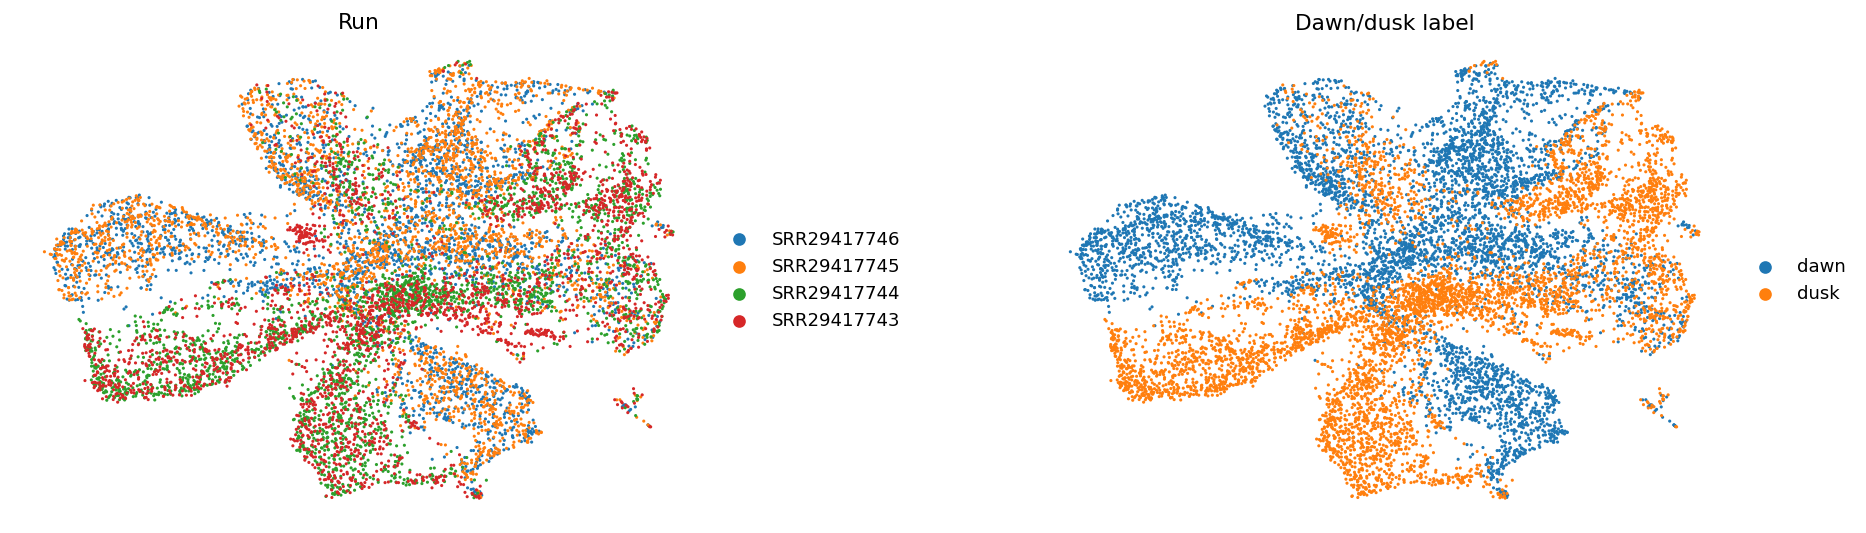

In [6]:
sc.pl.umap(
    combined,
    color=["run", "condition"],
    wspace=0.35,
    size=12,
    frameon=False,
    title=["Run", "Dawn/dusk label"],
)


### 2. UMAP by QC metrics

UMI and detected-gene depth are plotted to check whether major UMAP regions are driven mainly by sequencing depth.


In [7]:
qc_colors = [c for c in ["raw_umis", "raw_genes"] if c in combined.obs.columns]
if qc_colors:
    sc.pl.umap(
        combined,
        color=qc_colors,
        size=12,
        frameon=False,
        cmap="viridis",
        title=["Raw UMIs per cell", "Raw genes per cell"][:len(qc_colors)],
    )
else:
    print("No per-cell raw_umis/raw_genes columns were available in the combined normalized objects.")
    print("Use the run-level QC notebook for median UMI/gene comparisons.")


No per-cell raw_umis/raw_genes columns were available in the combined normalized objects.
Use the run-level QC notebook for median UMI/gene comparisons.


### 3. UMAP by native clusters and model predictions

This is the central check: accepted model labels are more useful if they occupy coherent regions or clusters in native Wolffia expression space.


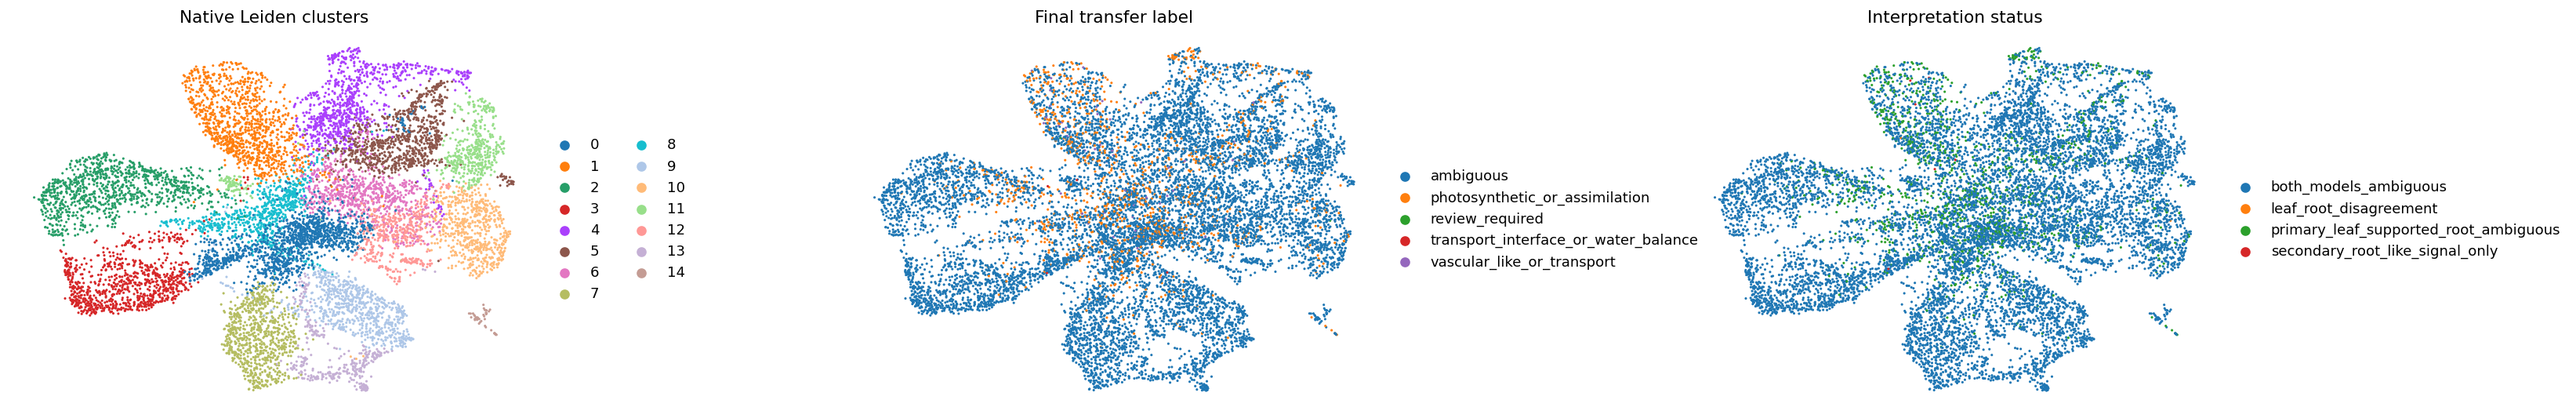

In [8]:
sc.pl.umap(
    combined,
    color=["leiden", "final_label", "interpretation_status"],
    size=12,
    frameon=False,
    wspace=0.45,
    title=["Native Leiden clusters", "Final transfer label", "Interpretation status"],
)


### 4. Cluster-by-label composition

The table below quantifies whether transfer labels are concentrated in specific native clusters. A coherent label should be enriched in a subset of clusters instead of being evenly scattered.


In [9]:
cluster_label_counts = pd.crosstab(combined.obs["leiden"], combined.obs["final_label"])
cluster_label_fractions = cluster_label_counts.div(cluster_label_counts.sum(axis=1), axis=0)
cluster_label_counts


final_label,ambiguous,photosynthetic_or_assimilation,review_required,transport_interface_or_water_balance,vascular_like_or_transport
leiden,,,,,
0,1184,193,0,1,9
1,791,254,1,1,25
2,915,88,0,1,1
3,884,18,0,0,1
4,803,91,0,0,1
5,770,88,0,0,5
6,698,85,0,0,4
7,768,15,0,0,0
8,572,153,0,0,10


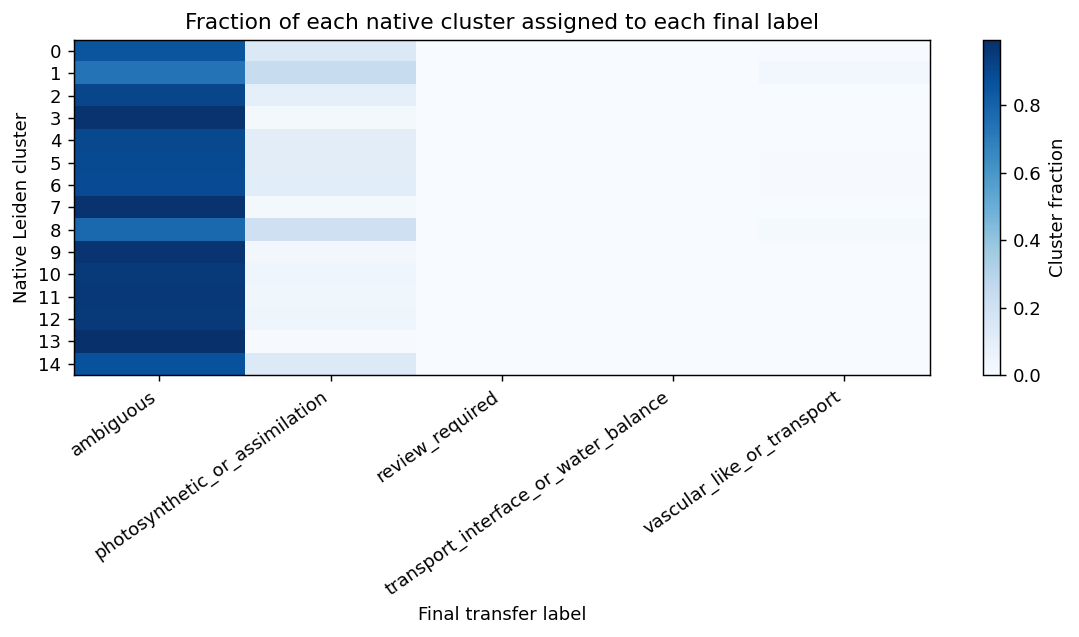

final_label,ambiguous,photosynthetic_or_assimilation,review_required,transport_interface_or_water_balance,vascular_like_or_transport
leiden,,,,,
0,0.854,0.139,0.000,0.001,0.006
1,0.738,0.237,0.001,0.001,0.023
2,0.910,0.088,0.000,0.001,0.001
3,0.979,0.020,0.000,0.000,0.001
4,0.897,0.102,0.000,0.000,0.001
5,0.892,0.102,0.000,0.000,0.006
6,0.887,0.108,0.000,0.000,0.005
7,0.981,0.019,0.000,0.000,0.000
8,0.778,0.208,0.000,0.000,0.014


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
image = ax.imshow(cluster_label_fractions.values, aspect="auto", cmap="Blues", vmin=0, vmax=max(0.01, cluster_label_fractions.values.max()))
ax.set_xticks(np.arange(cluster_label_fractions.shape[1]))
ax.set_xticklabels(cluster_label_fractions.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(cluster_label_fractions.shape[0]))
ax.set_yticklabels(cluster_label_fractions.index)
ax.set_xlabel("Final transfer label")
ax.set_ylabel("Native Leiden cluster")
ax.set_title("Fraction of each native cluster assigned to each final label")
fig.colorbar(image, ax=ax, label="Cluster fraction")
plt.tight_layout()
plt.show()

cluster_label_fractions.round(3)


### 5. Native marker genes for combined clusters

The next table lists top marker genes for each native cluster. These markers are the starting point for deciding whether a cluster is photosynthetic/assimilation-like, vascular/transport-like, stress-associated, or Wolffia-specific.


In [11]:
sc.tl.rank_genes_groups(
    combined,
    groupby="leiden",
    method="wilcoxon",
    use_raw=False,
    n_genes=20,
)
marker_table = sc.get.rank_genes_groups_df(combined, group=None)
marker_table = marker_table.rename(columns={"group": "leiden_cluster", "names": "waus8730_gene_id"})
marker_table = marker_table.sort_values(["leiden_cluster", "scores"], ascending=[True, False])
marker_table.head(20)


ranking genes


    finished (0:00:05)


,leiden_cluster,waus8730_gene_id,scores,logfoldchanges,pvals,pvals_adj
0,0,Waus8730.v1.chr7.g133850,36.027920,2.707882,3.058351e-284,4.611994e-280
1,0,Waus8730.v1.chr3.g090140,23.690567,1.315724,4.510587e-124,2.429273e-121
2,0,Waus8730.v1.chr13.g040080,21.661888,1.479723,4.695957e-104,1.180251e-101
3,0,Waus8730.v1.chr14.g042830,20.356716,1.342877,4.048276e-92,7.182117e-90
4,0,Waus8730.v1.chr12.g028420,18.638826,1.729405,1.556149e-77,1.372323e-75
5,0,Waus8730.v1.chr14.g042390,17.805534,0.523353,6.401765e-71,3.713023e-69
6,0,Waus8730.v1.chr8.g139480,16.835701,0.530677,1.335977e-63,5.074695e-62
7,0,Waus8730.v1.chr6.g118140,16.745443,0.807854,6.113403e-63,2.259562e-61
8,0,Waus8730.v1.chr11.g023670,16.223022,0.758617,3.467062e-59,1.013242e-57
9,0,Waus8730.v1.chr2.g084870,15.601933,0.936901,7.062276e-55,1.638448e-53


In [12]:
annotation_candidates = [
    EXTERNAL_ROOT / "results/waus8730_bridge/waus8730_functional_annotation.csv",
    PROJECT_ROOT / "data/metadata/waus8730_bridge/waus8730_functional_annotation.csv",
]
annotation_path = next((p for p in annotation_candidates if p.exists()), None)

if annotation_path is not None:
    annotation = pd.read_csv(annotation_path)
    if "waus8730_gene_id" in annotation.columns:
        description_columns = [
            c for c in annotation.columns
            if c in {"eggnog_free_text_desc", "Preferred_name", "Description", "description", "eggNOG_OGs"}
        ]
        keep = ["waus8730_gene_id"] + description_columns
        marker_table_annotated = marker_table.merge(
            annotation[keep].drop_duplicates("waus8730_gene_id"),
            on="waus8730_gene_id",
            how="left",
        )
    else:
        marker_table_annotated = marker_table.copy()
else:
    marker_table_annotated = marker_table.copy()

out_dir = EXTERNAL_ROOT / "results/combined_public_wolffia"
out_dir.mkdir(parents=True, exist_ok=True)
marker_path = out_dir / "four_run_leiden_marker_genes.csv"
composition_path = out_dir / "four_run_cluster_label_composition.csv"

marker_table_annotated.to_csv(marker_path, index=False)
cluster_label_fractions.to_csv(composition_path)

print("Wrote:", marker_path)
print("Wrote:", composition_path)
marker_table_annotated.head(30)


Wrote: /Volumes/LaCie/wolffia_single_cell/results/combined_public_wolffia/four_run_leiden_marker_genes.csv
Wrote: /Volumes/LaCie/wolffia_single_cell/results/combined_public_wolffia/four_run_cluster_label_composition.csv


,leiden_cluster,waus8730_gene_id,scores,logfoldchanges,pvals,pvals_adj,Description,Preferred_name,eggNOG_OGs
0,0,Waus8730.v1.chr7.g133850,36.027920,2.707882,3.058351e-284,4.611994e-280,Involved in biosynthesis of the thiamine precu...,THI1,"COG1635@1|root,KOG2960@2759|Eukaryota,37J38@33..."
1,0,Waus8730.v1.chr3.g090140,23.690567,1.315724,4.510587e-124,2.429273e-121,glycine-rich RNA-binding,GRP1,"KOG0118@1|root,KOG0118@2759|Eukaryota,37U6A@33..."
2,0,Waus8730.v1.chr13.g040080,21.661888,1.479723,4.695957e-104,1.180251e-101,fructose-bisphosphate aldolase,-,"COG3588@1|root,KOG1557@2759|Eukaryota,37KBJ@33..."
3,0,Waus8730.v1.chr14.g042830,20.356716,1.342877,4.048276e-92,7.182117e-90,14 kDa proline-rich protein,-,"2C12H@1|root,2RZES@2759|Eukaryota,37UZ3@33090|..."
4,0,Waus8730.v1.chr12.g028420,18.638826,1.729405,1.556149e-77,1.372323e-75,CBS domain,-,"COG1900@1|root,2RY2M@2759|Eukaryota,37TSV@3309..."
5,0,Waus8730.v1.chr14.g042390,17.805534,0.523353,6.401765e-71,3.713023e-69,Participates in electron transfer between P700...,PETE,"COG3794@1|root,2RXIY@2759|Eukaryota,37TZA@3309..."
6,0,Waus8730.v1.chr8.g139480,16.835701,0.530677,1.335977e-63,5.074695e-62,Photosystem I reaction center subunit,psaD,"28I81@1|root,2QQIC@2759|Eukaryota,37I0I@33090|..."
7,0,Waus8730.v1.chr6.g118140,16.745443,0.807854,6.113403e-63,2.259562e-61,Ferredoxins are iron-sulfur proteins that tran...,-,"COG0633@1|root,2S1GZ@2759|Eukaryota,37VM8@3309..."
8,0,Waus8730.v1.chr11.g023670,16.223022,0.758617,3.467062e-59,1.013242e-57,RuBisCO catalyzes two reactions the carboxylat...,-,"COG4451@1|root,2QT0M@2759|Eukaryota,37T3C@3309..."
9,0,Waus8730.v1.chr2.g084870,15.601933,0.936901,7.062276e-55,1.638448e-53,29 kDa ribonucleoprotein,-,"KOG0118@1|root,KOG0118@2759|Eukaryota,37NJY@33..."


## Takeaways

1. **This notebook provides the first combined cell-level view of the four public Wolffia runs.** It moves the project beyond per-run metrics into native expression-space review.
2. **The most important visual check is whether accepted labels occupy coherent UMAP regions and Leiden clusters.** This determines whether the transfer model is capturing stable Wolffia expression neighborhoods or only assigning scattered cells.
3. **Cluster-marker interpretation should now guide label refinement.** The exported marker table can be reviewed for photosynthesis, transport, stress, growth, and Wolffia-specific signals.
4. **Dawn/dusk differences should remain tentative.** If condition structure overlaps with QC or run separation, we should avoid biological claims until marker review supports them.
5. **The next project step is to annotate the combined native clusters.** Start with the clusters enriched for `photosynthetic_or_assimilation`, then review smaller vascular/transport-like and ambiguous-enriched clusters.
